# Detecting expr1.timer combined plot (0615, hosts side-by-side)

Same per-timer histogram + measured/theoretical CDF as 0614, but all hosts are drawn in a
single figure arranged horizontally: rows = timers, columns = host x [Histogram, CDF].
Loading, cntvct cleanup, timer-label mapping and font config are identical to 0614.

In [1]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set one shuffle at a time; do not aggregate shuffle0/1/2 in one plot.
# Host order is gnr, amd, c920bn3.
RUN_ROOTS_SHUFFLE0 = [
    Path('/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle0/'),
    Path('/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle0/'),
    Path('/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle0/'),
]
RUN_ROOTS_SHUFFLE1 = [
    Path('/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle1/'),
    Path('/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle1/'),
    Path('/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle1/'),
]
RUN_ROOTS_SHUFFLE2 = [
    Path('/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle2/'),
    Path('/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle2/'),
    Path('/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle2/'),
]
RUN_ROOTS = RUN_ROOTS_SHUFFLE1

# Single flush size to plot (expr1.timer view); 16 KiB matches the 0611 notebook.
FSIZE_KIB = 2048
# Drop the top tail of measured samples before plotting (per timer).
QUANTILE_DROP = 1.0
# CDF x-range; set to a (lo, hi) tuple to fix it, or None to autoscale.
CDF_XLIM = None
# Measured-histogram bin count (was hard-capped at 20). int, or 'auto'/'fd' for numpy adaptive.
HIST_BINS = 30
# Histogram x-range upper bound = this quantile of measured, so a heavy tail
# does not collapse the body into one bar (independent of QUANTILE_DROP/CDF).
HIST_XLIM_QUANTILE = 0.99

# ---- font sizes (tune here) ----
ROWLABEL_FONTSIZE   = 12   # timer name (hist y-label)
AXIS_LABEL_FONTSIZE = 11   # Time(ns) / CDF labels
TICK_FONTSIZE       = 10
LEGEND_FONTSIZE     = 12
COLTITLE_FONTSIZE   = 14   # 'Histogram' / 'Execution Time Distribution'
SUPTITLE_FONTSIZE   = 15   # host title


def host_from_root(root):
    parts = list(root.parts)
    if '20260615' in parts:
        idx = parts.index('20260615')
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return parts[-6] if len(parts) >= 6 else root.name


HOST_ORDER = [host_from_root(root) for root in RUN_ROOTS]

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'scripts':
    REPO_ROOT = REPO_ROOT.parent
OUT_DIR = REPO_ROOT / 'scripts_plot/outputDetecting'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TIMER_COLORS = {
    'clock_gettime': '#ff7f0e',
    'cgt': '#ff7f0e',
    'mpi_wtime': '#2ca02c',
    'wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#1f77b4',
    'tsc_native': '#17becf',
    'tsc_asym': '#7f7f7f',
    'cntvct': '#00a6d6',
    'cntvct_fence': '#00a6d6',
    'cntvcto': '#e377c2',
}

HOST_LABELS = {
    'c920bn3': 'Kunpeng 920B',
    'camd9554n2': 'AMD EPYC 9554',
    'camd9554n1': 'AMD EPYC 9554',
    'cgnr6760pn2': 'Intel Xeon 6760P',
}

DROP_TIMERS = {'cntvct_fence', 'tsc_asym'}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))
RUN_TAG = f'multi_host_{RUN_ROOTS[0].name}' if len(RUN_ROOTS) > 1 else RUN_ROOTS[0].name

SAVE_FIG = True

for root in RUN_ROOTS:
    print(root)
print('host_order:', HOST_ORDER)

/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle1
/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle1
/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle1
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']


In [2]:
def parse_meta(path):
    d = {}
    if not path.exists():
        return d
    for line in path.read_text(errors='ignore').splitlines():
        if '=' in line:
            k, v = line.split('=', 1)
            d[k.strip()] = v.strip()
    return d


def read_values(path):
    vals = []
    for line in path.read_text(errors='ignore').splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        try:
            vals.append(float(line.split(',')[-1]))
        except ValueError:
            pass
    return vals


def ta_from_run_dir(run_dir, meta):
    for key in ('ta', 'mu_ns', 'interval_ns'):
        if key in meta:
            try:
                return float(meta[key])
            except ValueError:
                pass
    m = re.search(r'_ta([0-9]+(?:\.[0-9]+)?)', run_dir.name)
    if m:
        return float(m.group(1))
    return math.nan


def ecdf(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.array([]), np.array([])
    xs = np.sort(vals)
    ys = np.arange(1, xs.size + 1) / xs.size
    return xs, ys

In [3]:
rows = []
for run_root in RUN_ROOTS:
    for cdf in sorted(run_root.rglob('*_ta_cdf.csv')):
        run_dir = cdf.parent
        combo_dir = run_dir.parent
        meta = parse_meta(run_dir / 'meta.txt') or parse_meta(combo_dir / 'meta.txt')
        measured = read_values(cdf)
        if not measured:
            continue
        ta = ta_from_run_dir(run_dir, meta)
        rows.append({
            'run_root': str(run_root),
            'host': meta.get('host', host_from_root(run_root)),
            'expr': meta.get('expr_name', run_root.name),
            'np': int(float(meta.get('np', 0) or 0)),
            'timer': meta.get('timer', cdf.parents[2].name),
            'interval_ns': int(float(meta.get('interval_ns', meta.get('mu_ns', 0)) or 0)),
            'fsize_kib': int(float(meta.get('fsize_kib', 0) or 0)),
            'fkern': meta.get('fkern', ''),
            'rkern': meta.get('rkern', ''),
            'walk_id': int(float(meta.get('walk_id', 0) or 0)),
            'ta': ta,
            'measured': measured,
            'theory': [ta] * len(measured),
            'n_measured': len(measured),
            'run_dir': str(run_dir),
        })

raw = pd.DataFrame(rows)
print(f'cdf files: {len(raw)}')
if raw.empty:
    raise RuntimeError('No *_ta_cdf.csv files found under RUN_ROOTS')

raw = raw[~raw['timer'].isin(DROP_TIMERS)].copy()
# drop the real cntvct, keep cntvcto and rename it to cntvct (displayed as CNTVCT)
raw = raw[raw['timer'] != 'cntvct'].copy()
raw['timer'] = raw['timer'].replace('cntvcto', 'cntvct')
raw_min = raw[raw['fsize_kib'] == FSIZE_KIB].copy()
if raw_min.empty:
    raise RuntimeError(f'No rows with fsize_kib == {FSIZE_KIB}')
raw_min['hostname'] = raw_min['host'].map(HOST_LABELS).fillna(raw_min['host'])
print(raw_min.groupby(['host', 'timer', 'fsize_kib']).size().reset_index(name='walk_files').to_string(index=False))
# print(raw_min['np'].unique())

cdf files: 4180
       host         timer  fsize_kib  walk_files
    c920bn3 clock_gettime       2048          20
    c920bn3        cntvct       2048          20
    c920bn3     mpi_wtime       2048          20
    c920bn3          papi       2048          20
    c920bn3        papix6       2048          20
 camd9554n1 clock_gettime       2048          20
 camd9554n1     mpi_wtime       2048          20
 camd9554n1          papi       2048          20
 camd9554n1        papix6       2048          20
 camd9554n1           tsc       2048          20
cgnr6760pn2 clock_gettime       2048          20
cgnr6760pn2     mpi_wtime       2048          20
cgnr6760pn2          papi       2048          20
cgnr6760pn2        papix6       2048          20
cgnr6760pn2           tsc       2048          20


[expr1.timer combined]  fsize=2048KiB  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']


/astrum/home/hpchzy/code/TacVar/scripts_plot/outputDetecting/detecting_expr1_timer_0615_multi_host_detecting.expr2.fsize.shuffle1_combined.png


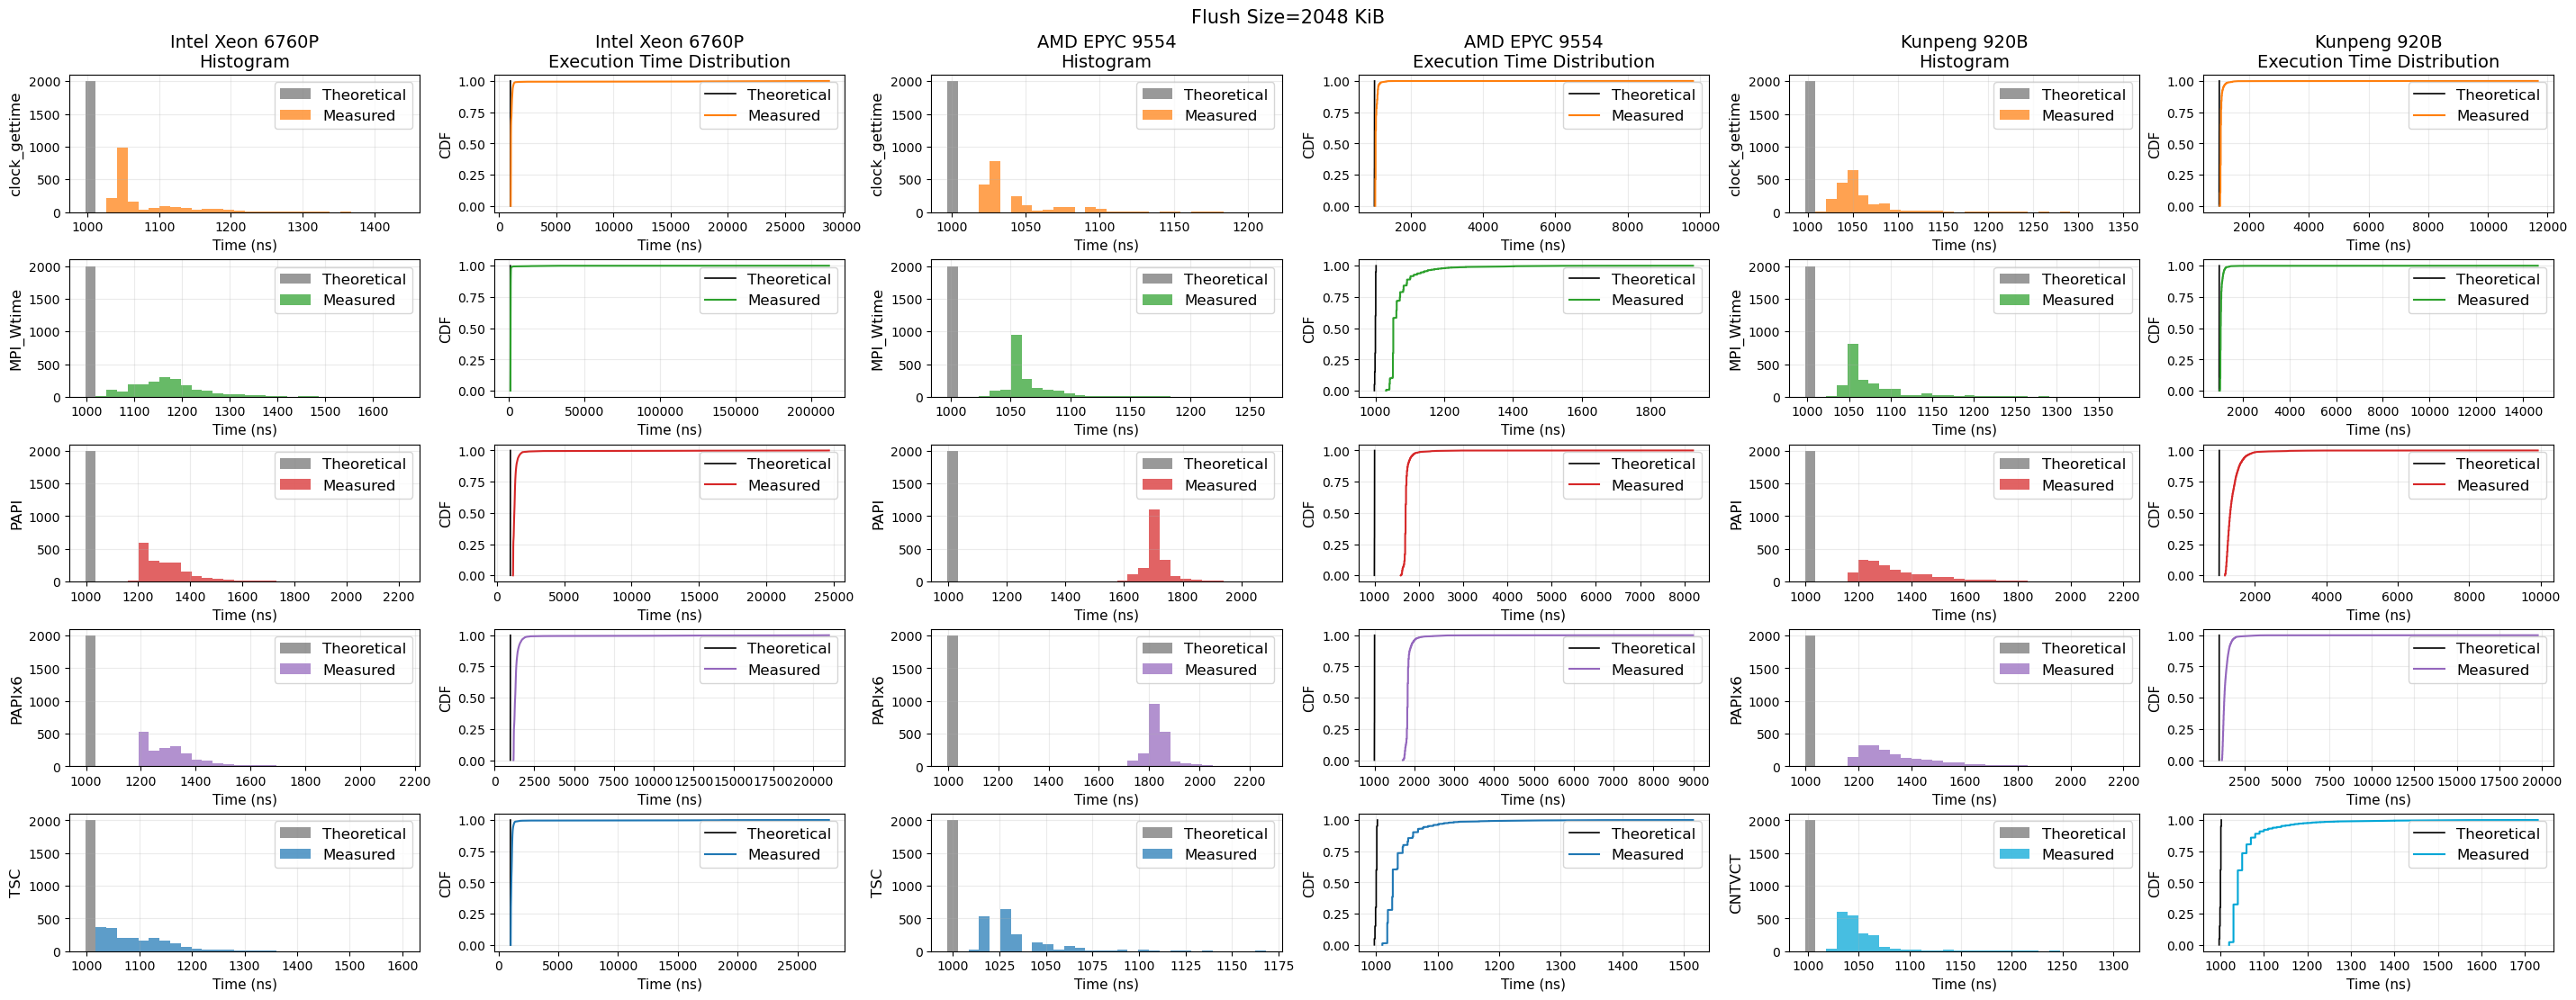

In [4]:
# Combined figure: hosts arranged horizontally.
# Grid = (rows = timers) x (cols = host x [Histogram, CDF]).
hosts = [h for h in HOST_ORDER if h in set(raw_min['host'])]


def host_timer_list(host_df):
    timers = [t for t in TIMER_COLORS if t in set(host_df['timer'])]
    timers += [t for t in sorted(host_df['timer'].unique()) if t not in timers]
    return timers


host_timers = {h: host_timer_list(raw_min[raw_min['host'] == h]) for h in hosts}
nrows = max((len(v) for v in host_timers.values()), default=0)
ncols = len(hosts) * 2
fsize = int(raw_min['fsize_kib'].min())

print(f'[expr1.timer combined]  fsize={fsize}KiB  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
fig, axes = plt.subplots(nrows, ncols, figsize=(9.5 * len(hosts), 2.2 * max(1, nrows)), squeeze=False, constrained_layout=True)

for hi, host in enumerate(hosts):
    host_df = raw_min[raw_min['host'] == host]
    timers = host_timers[host]
    col_h, col_c = 2 * hi, 2 * hi + 1
    for row_idx in range(nrows):
        ax_hist = axes[row_idx][col_h]
        ax_cdf = axes[row_idx][col_c]
        if row_idx >= len(timers):
            ax_hist.axis('off')
            ax_cdf.axis('off')
            continue

        timer = timers[row_idx]
        tdf = host_df[host_df['timer'] == timer]
        measured = np.array([x for vals in tdf['measured'] for x in vals], dtype=float)
        if measured.size:
            quantile_drop = np.quantile(measured, QUANTILE_DROP)
            measured = measured[measured <= quantile_drop]
        theory = np.array([x for vals in tdf['theory'] for x in vals], dtype=float)
        color = TIMER_COLORS.get(timer)

        if measured.size:
            hist_hi = float(np.quantile(measured, HIST_XLIM_QUANTILE))
            hist_lo = float(min(measured.min(), theory.min() if theory.size else measured.min()))
            hist_range = (hist_lo, hist_hi) if hist_hi > hist_lo else None
        else:
            hist_range = None

        ax_hist.hist(theory, bins=HIST_BINS, range=hist_range, alpha=0.40, color='black', label='Theoretical')
        ax_hist.hist(measured, bins=HIST_BINS, range=hist_range, alpha=0.72, color=color, label='Measured')
        ax_hist.set_ylabel(timer_label(timer), fontsize=ROWLABEL_FONTSIZE)
        ax_hist.set_xlabel('Time (ns)', fontsize=AXIS_LABEL_FONTSIZE)
        ax_hist.grid(True, alpha=0.25)
        ax_hist.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        ax_hist.legend(fontsize=LEGEND_FONTSIZE)

        tx, ty = ecdf(theory)
        mx, my = ecdf(measured)
        ax_cdf.plot(tx, ty, linewidth=1.2, color='black', label='Theoretical')
        ax_cdf.plot(mx, my, linewidth=1.5, color=color, label='Measured')
        ax_cdf.set_xlabel('Time (ns)', fontsize=AXIS_LABEL_FONTSIZE)
        ax_cdf.set_ylabel('CDF', fontsize=AXIS_LABEL_FONTSIZE)
        ax_cdf.grid(True, alpha=0.25)
        ax_cdf.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        ax_cdf.legend(fontsize=LEGEND_FONTSIZE)
        if CDF_XLIM is not None:
            ax_cdf.set_xlim(*CDF_XLIM)

        if row_idx == 0:
            ax_hist.set_title(f"{HOST_LABELS.get(host, host)}\nHistogram", fontsize=COLTITLE_FONTSIZE)
            ax_cdf.set_title(f"{HOST_LABELS.get(host, host)}\nExecution Time Distribution", fontsize=COLTITLE_FONTSIZE)

fig.suptitle(f"Flush Size={fsize} KiB", fontsize=SUPTITLE_FONTSIZE)

if SAVE_FIG:
    out = OUT_DIR / f'detecting_expr1_timer_0615_{RUN_TAG}_combined.png'
    fig.savefig(out, dpi=220, bbox_inches='tight')
    print(out)
plt.show()